In [1]:
pip install plotly seaborn matplotlib numpy pandas kaleido

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
  Attempting uninstall: platformdirs
   ---------------------------------------- 0/6 [simplejson]
   ------ --------------------------------- 1/6 [platformdirs]
    Found existing installation: platformdirs 4.2.2
   ------ --------------------------------- 1/6 [platformdirs]
    Uninstalling platformdirs-4.2.2:
   ------ --------------------------------- 1/6 [platformdirs]
      Successfully uninstalled platformdirs-4.2.2
   ------ --------------------------------- 1/6 [platformdirs]
   ------ --------------------------------- 1/6 [platformdirs]
   -------------------- ------------------- 3/6 [logistro]
   --

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

C:\Users\rimpa\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

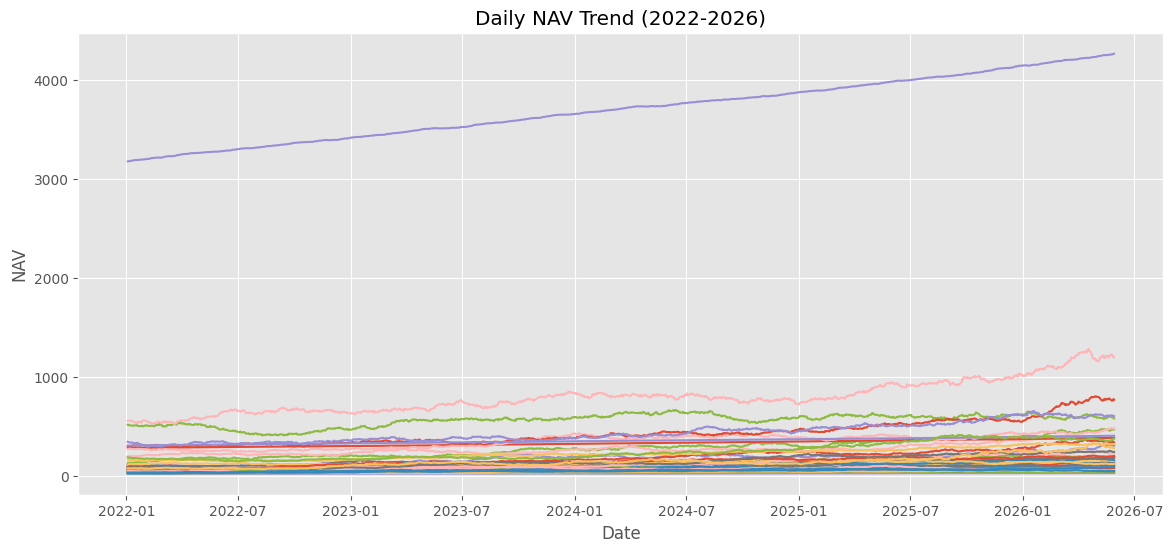

In [44]:
import matplotlib.pyplot as plt

nav['date'] = pd.to_datetime(nav['date'])

plt.figure(figsize=(14,6))

for fund in nav['amfi_code'].unique():
    data = nav[nav['amfi_code'] == fund]

    plt.plot(
        data['date'],
        data['nav'],
        label=str(fund)
    )

plt.title('Daily NAV Trend (2022-2026)')
plt.xlabel('Date')
plt.ylabel('NAV')

# Save PNG
plt.savefig(
    "../reports/nav_trend.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [4]:
aum['date'] = pd.to_datetime(aum['date'],format='%Y-%m-%d')

aum['year'] = aum['date'].dt.year

print(aum[['date','year']].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


In [5]:
aum_yearly = (
    aum.groupby(['year', 'fund_house'])['aum_crore']
       .mean()
       .reset_index()
)

print(aum_yearly.head())

   year                fund_house  aum_crore
0  2022  Aditya Birla Sun Life MF   281500.0
1  2022          Axis Mutual Fund   245000.0
2  2022           DSP Mutual Fund   111000.0
3  2022          HDFC Mutual Fund   440000.0
4  2022       ICICI Prudential MF   476500.0


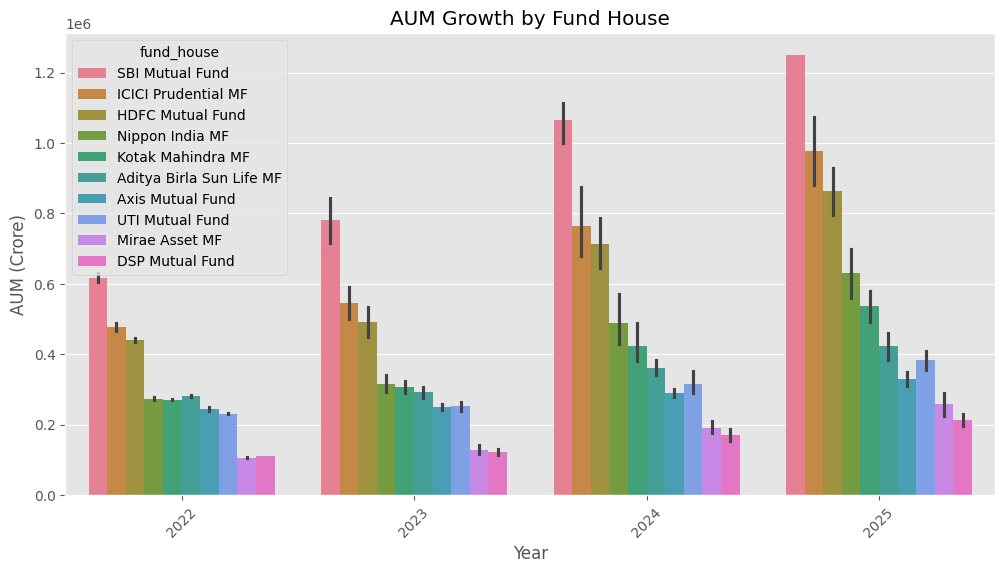

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House")
plt.ylabel("AUM (Crore)")
plt.xlabel("Year")

plt.xticks(rotation=45)

# Save PNG
plt.savefig(
    "../reports/aum_growth.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [7]:
sip['month'] = pd.to_datetime(sip['month'])

In [8]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend (2022-2025)'
)

fig.show()

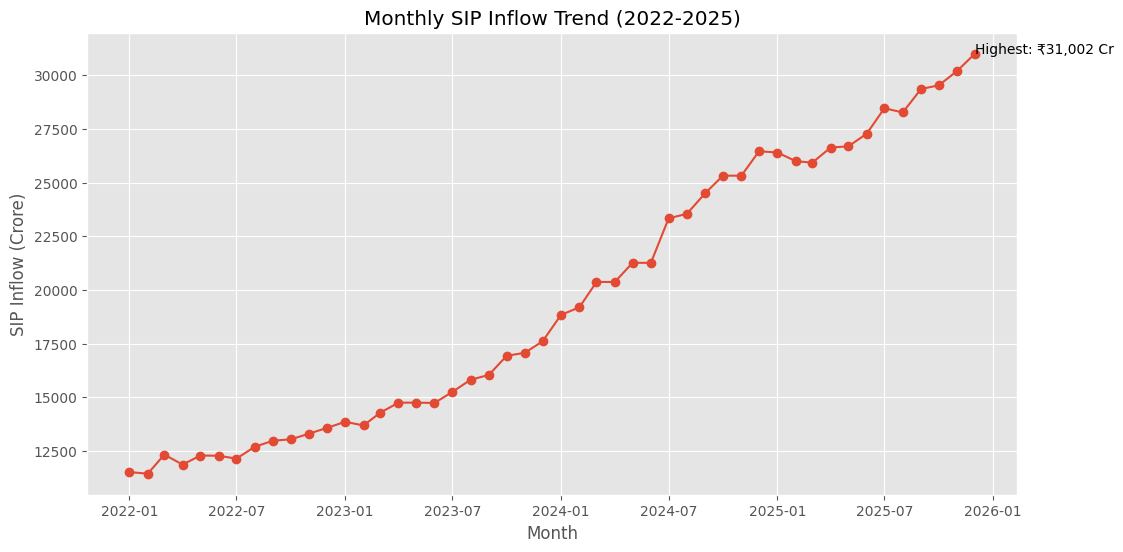

In [46]:
import matplotlib.pyplot as plt

max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]

plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.annotate(
    f"Highest: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    (
        max_row['month'],
        max_row['sip_inflow_crore']
    )
)

plt.title('Monthly SIP Inflow Trend (2022-2025)')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore)')

# Save PNG
plt.savefig(
    "../reports/sip_inflow_trend.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [10]:
import kaleido

print("Kaleido Installed Successfully")

Kaleido Installed Successfully


In [19]:
category['month'] = pd.to_datetime(category['month'])

In [20]:
heatmap_data = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month',
    aggfunc='sum'
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


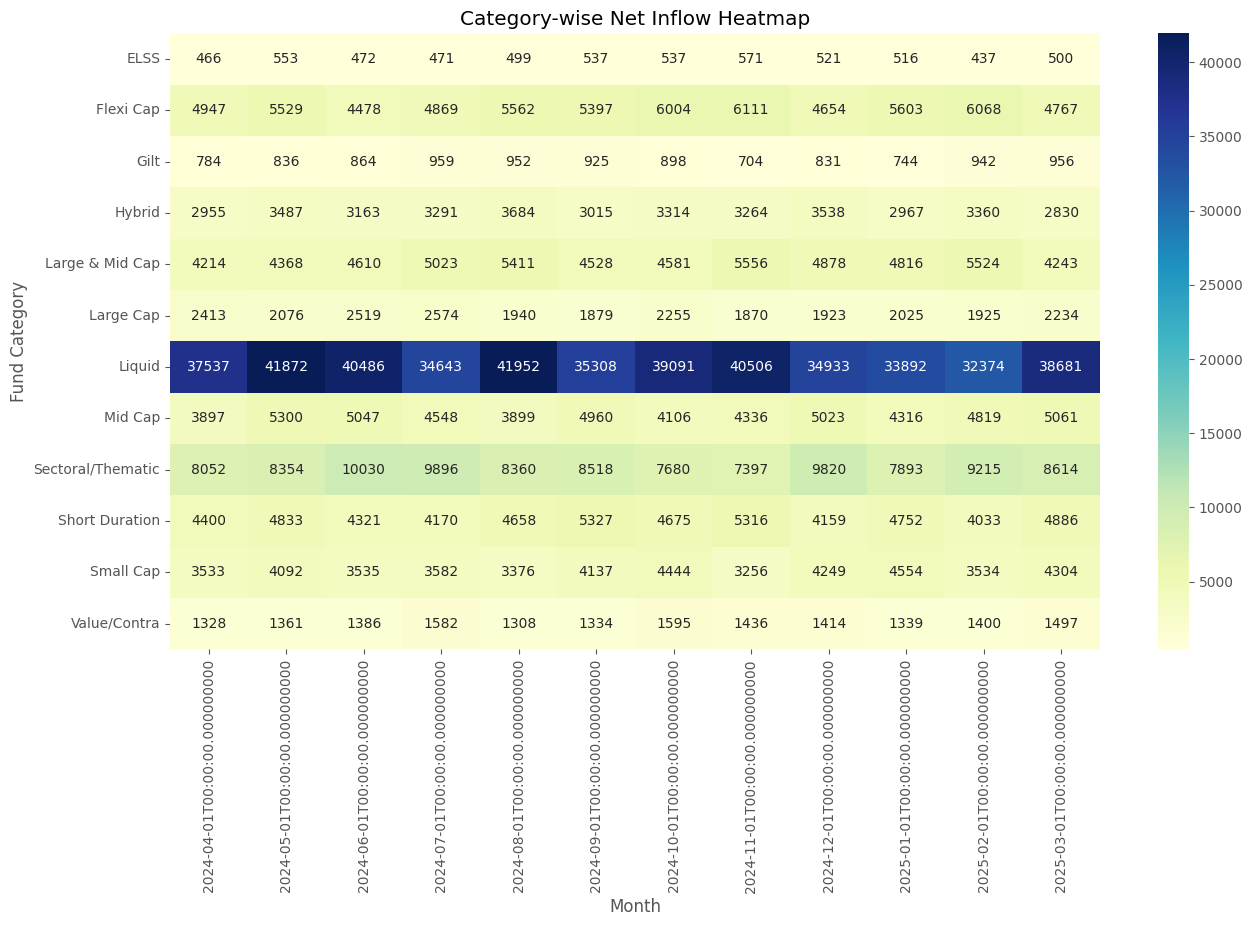

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f'
)

plt.title('Category-wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')

# Save PNG
plt.savefig(
    "../reports/category_heatmap.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

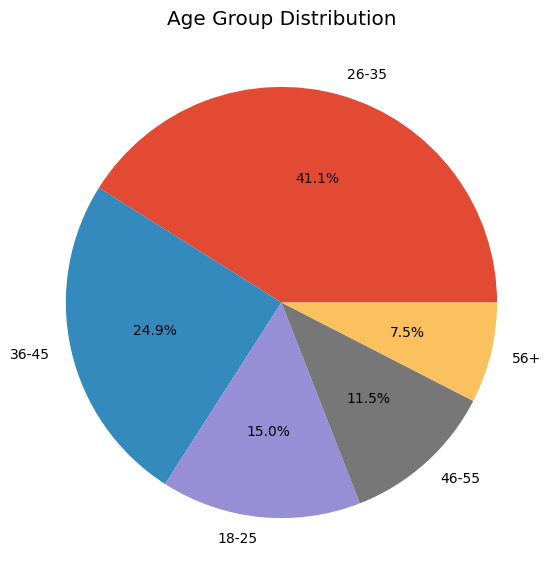

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Age Group Distribution")
plt.ylabel('')

# Save PNG
plt.savefig(
    "../reports/age_group_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

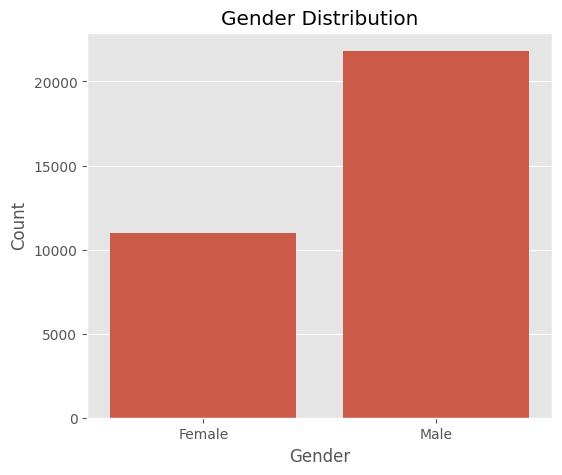

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    data=transactions,
    x='gender'
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

# Save PNG
plt.savefig(
    "../reports/gender_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

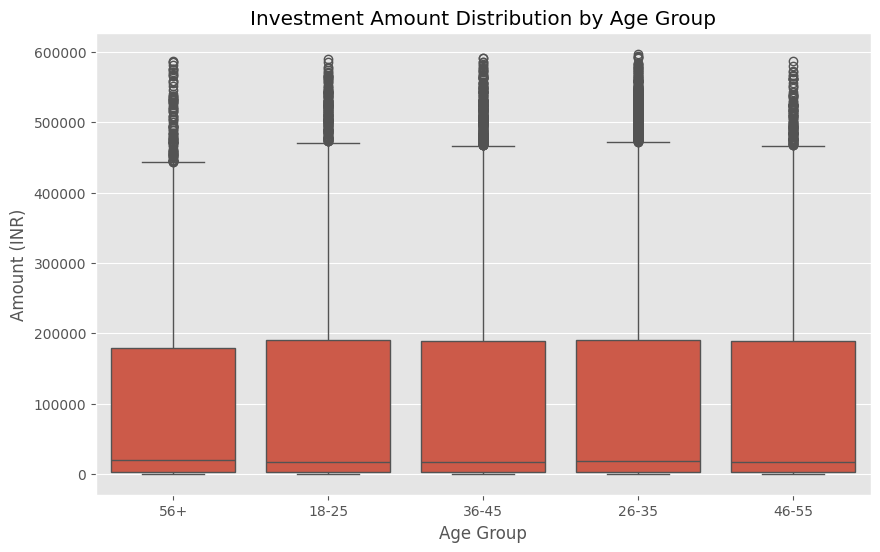

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

# Save PNG
plt.savefig(
    "../reports/sip_amount_boxplot.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

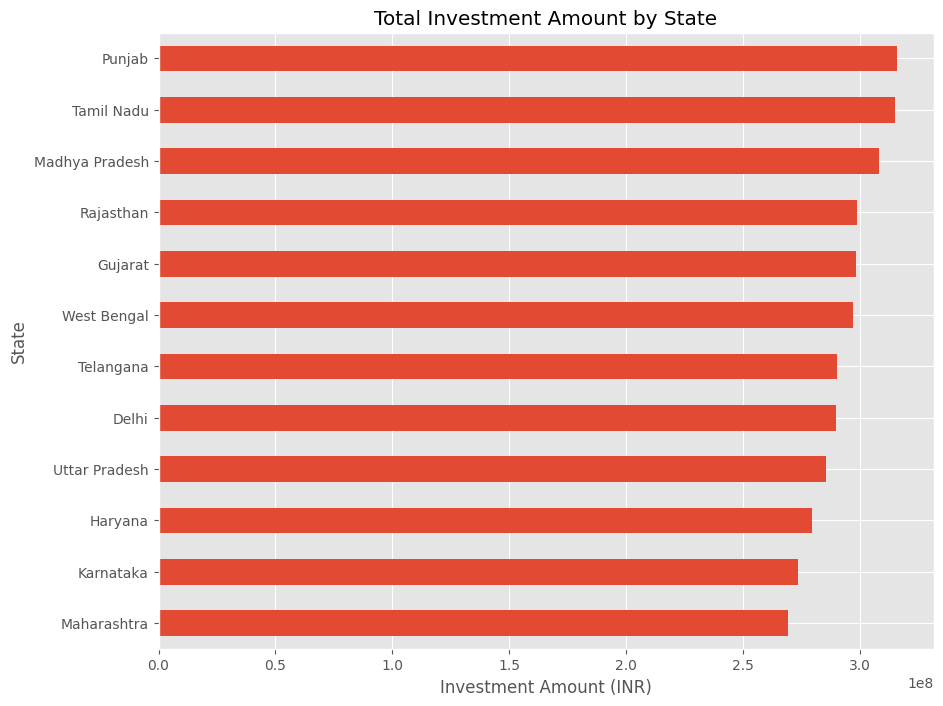

In [51]:
import matplotlib.pyplot as plt

state_sip = transactions.groupby(
    'state'
)['amount_inr'].sum().sort_values()

plt.figure(figsize=(10,8))

state_sip.plot(
    kind='barh'
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

# Save PNG
plt.savefig(
    "../reports/state_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

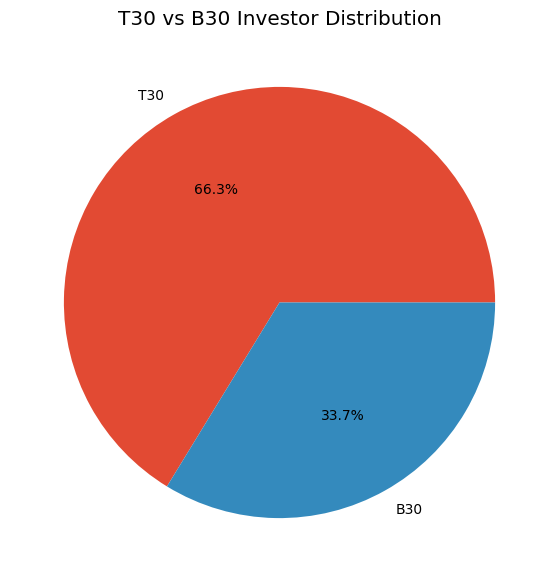

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel('')

# Save PNG
plt.savefig(
    "../reports/t30_b30_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [29]:
folio['month'] = pd.to_datetime(folio['month'])

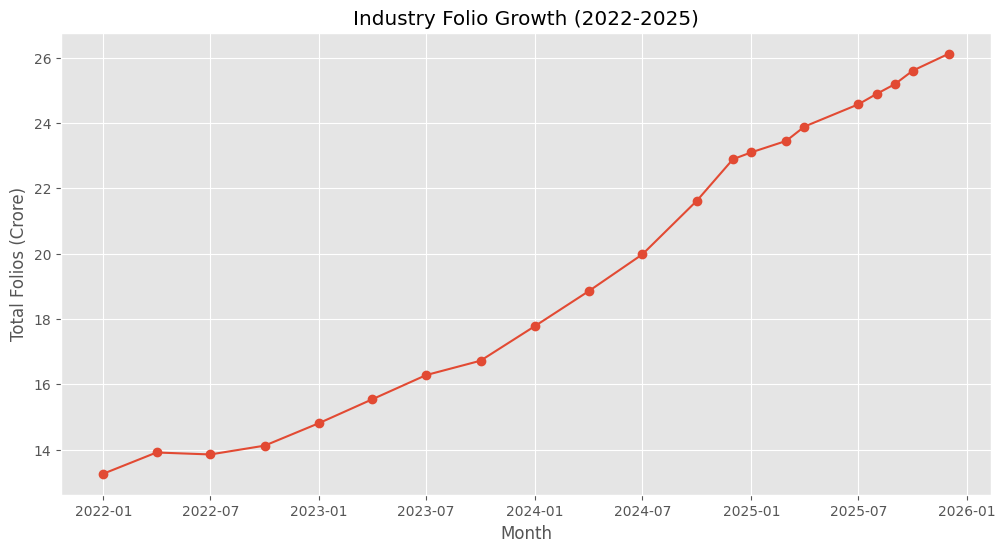

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title('Industry Folio Growth (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')

# Save PNG
plt.savefig(
    "../reports/folio_growth.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [31]:
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    markers=True,
    title='Industry Folio Growth (2022-2025)'
)

fig.add_annotation(
    x=folio.iloc[0]['month'],
    y=folio.iloc[0]['total_folios_crore'],
    text='13.26 Cr',
    showarrow=True
)

fig.add_annotation(
    x=folio.iloc[-1]['month'],
    y=folio.iloc[-1]['total_folios_crore'],
    text='26.12 Cr',
    showarrow=True
)

fig.show()

In [32]:
nav['date'] = pd.to_datetime(
    nav['date'],
    format='%d-%m-%Y'
)

In [33]:
selected_funds = nav['amfi_code'].unique()[:10]

nav_10 = nav[
    nav['amfi_code'].isin(selected_funds)
]

In [34]:
print(nav_10['amfi_code'].nunique())

10


In [35]:
nav_pivot = nav_10.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

nav_pivot.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [36]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660


In [37]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


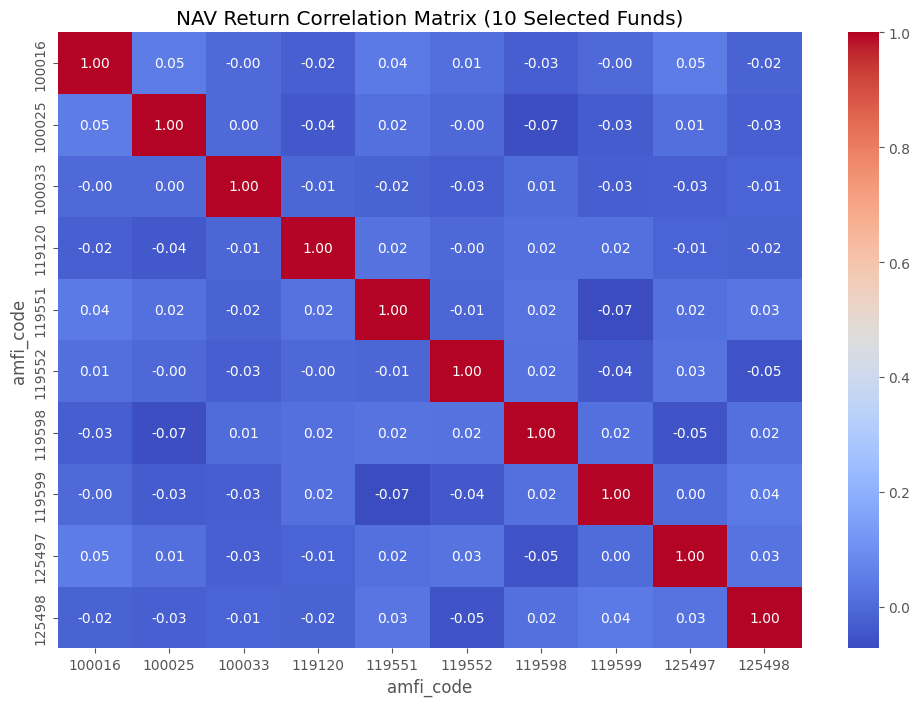

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'NAV Return Correlation Matrix (10 Selected Funds)'
)

# Save PNG
plt.savefig(
    "../reports/correlation_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [39]:
sector_allocation = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_allocation

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

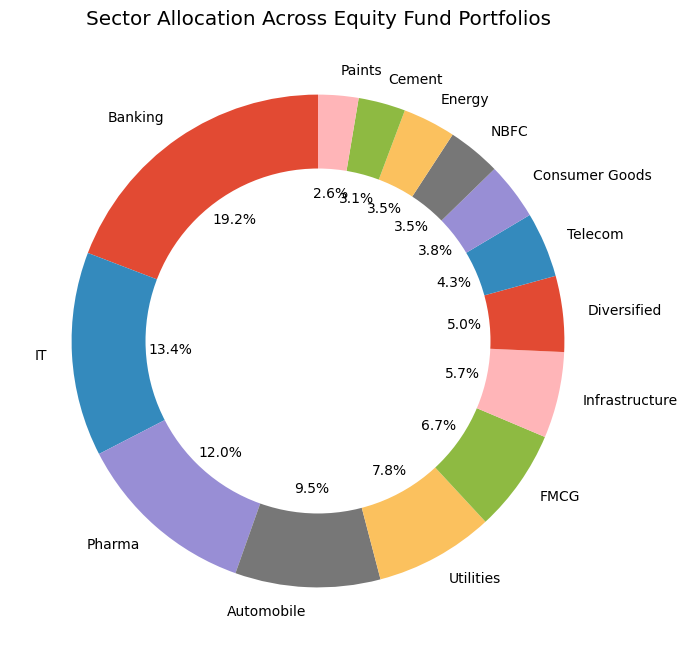

In [41]:
plt.figure(figsize=(10,8))

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct='%1.1f%%',
    startangle=90
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Fund Portfolios")

plt.savefig(
    "../reports/sector_allocation_donut.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [43]:
plt.savefig(
    "../reports/nav_trend.png",
    bbox_inches="tight",
    dpi=300
)

<Figure size 640x480 with 0 Axes>

# Key EDA Findings

### Finding 1
The majority of mutual fund schemes exhibited a long-term upward NAV trend from 2022 to 2025.

### Finding 2
Several schemes experienced temporary NAV declines during market correction periods.

### Finding 3
AUM is highly concentrated among a few large fund houses, with SBI Mutual Fund maintaining a dominant market position.

### Finding 4
Monthly SIP inflows showed consistent growth over the analysis period.

### Finding 5
Large Cap, Flexi Cap, and Large & Mid Cap categories attracted higher net inflows.

### Finding 6
The 26–45 age group contributed the largest share of mutual fund investments.

### Finding 7
T30 cities contributed a significantly larger share of investments than B30 cities.

### Finding 8
Total mutual fund folios increased steadily throughout the study period.

### Finding 9
Most selected funds showed positive return correlations.

### Finding 10
Banking, Utilities, and Diversified sectors accounted for a substantial portion of portfolio allocation.